# Part F: Model Evulation and Compersion

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import DecisionTreeRegressor

from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression

from sklearn.ensemble import (
    RandomForestClassifier,
    RandomForestRegressor,
    BaggingClassifier,
    BaggingRegressor,
    AdaBoostClassifier,
    AdaBoostRegressor,
    GradientBoostingClassifier,
    GradientBoostingRegressor,
    VotingClassifier,
    StackingClassifier,
    StackingRegressor
)

from sklearn.metrics import *

In [5]:
df = pd.read_excel("Smart_Outcome_Predictor_Dataset_5200.xlsx")

print(df.shape)

df.head()

(5200, 19)


,student_id,age,country_region,device_type,education_background,course_level,course_category,course_start_date,week_of_year,sessions,time_spent_hours,videos_watched,quiz_attempts,assignments_submitted,forum_posts,avg_quiz_score,attendance_rate,completion_status,final_score
0,700001,32,Europe,Laptop,Undergrad,Intermediate,Business,2024-03-18,12,1,7.6,1,6,1,1,53.3,0.655,0,49.8
1,700002,17,Europe,Laptop,Undergrad,Intermediate,Programming,2024-08-22,34,16,27.2,6,4,7,1,51.5,1.000,1,84.0
2,700003,25,Europe,Mobile,Graduate,Advanced,Programming,2024-09-28,39,6,7.1,16,2,2,0,62.2,0.810,0,62.5
3,700004,26,Asia,Mobile,Undergrad,Beginner,Design,2024-03-09,10,34,22.1,57,9,6,0,59.3,0.875,1,89.5
4,700005,26,Asia,Tablet,WorkingPro,Advanced,Business,2024-03-21,12,22,32.3,41,9,2,0,65.1,0.814,0,67.4


In [6]:
df['course_start_date'] = pd.to_datetime(df['course_start_date'])

df['course_year'] = df['course_start_date'].dt.year
df['course_month'] = df['course_start_date'].dt.month
df['course_day'] = df['course_start_date'].dt.day

df.drop('course_start_date',axis=1,inplace=True)

In [7]:
cat_cols = [
'country_region',
'device_type',
'education_background',
'course_level',
'course_category'
]

for col in cat_cols:

    le = LabelEncoder()

    df[col] = le.fit_transform(df[col].astype(str))

In [8]:
X_cls = df.drop(
    ['completion_status','final_score'],
    axis=1
)

y_cls = df['completion_status']

In [9]:
X_train_cls,X_test_cls,y_train_cls,y_test_cls=train_test_split(
X_cls,
y_cls,
test_size=0.20,
random_state=42,
stratify=y_cls
)

In [10]:
X_reg=df.drop(
['completion_status','final_score'],
axis=1
)

y_reg=df['final_score']

In [11]:
X_train_reg,X_test_reg,y_train_reg,y_test_reg=train_test_split(
X_reg,
y_reg,
test_size=0.20,
random_state=42
)

In [12]:
bag_clf=BaggingClassifier(
estimator=DecisionTreeClassifier(),
n_estimators=100,
random_state=42
)

bag_clf.fit(X_train_cls,y_train_cls)

y_pred_bag_cls=bag_clf.predict(X_test_cls)

bag_reg=BaggingRegressor(
estimator=DecisionTreeRegressor(),
n_estimators=100,
random_state=42
)

bag_reg.fit(X_train_reg,y_train_reg)

y_pred_bag_reg=bag_reg.predict(X_test_reg)

In [15]:
import pandas as pd
import numpy as np

print("Missing values in X_train_cls:")
print(pd.DataFrame(X_train_cls).isnull().sum())

print("Total NaN:", pd.DataFrame(X_train_cls).isnull().sum().sum())

Missing values in X_train_cls:
student_id                0
age                       0
country_region            0
device_type               0
education_background      0
course_level              0
course_category           0
week_of_year              0
sessions                  0
time_spent_hours         98
videos_watched            0
quiz_attempts             0
assignments_submitted     0
forum_posts               0
avg_quiz_score           65
attendance_rate          68
course_year               0
course_month              0
course_day                0
dtype: int64
Total NaN: 231


In [16]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_cls = imputer.fit_transform(X_train_cls)
X_test_cls = imputer.transform(X_test_cls)

In [17]:
import numpy as np

print("NaN in X_train_cls:", np.isnan(X_train_cls).sum())
print("NaN in X_test_cls :", np.isnan(X_test_cls).sum())

NaN in X_train_cls: 0
NaN in X_test_cls : 0


In [18]:
from sklearn.ensemble import AdaBoostClassifier

ada_clf = AdaBoostClassifier(
    n_estimators=100,
    random_state=42
)

ada_clf.fit(X_train_cls, y_train_cls)

y_pred_ada_cls = ada_clf.predict(X_test_cls)

print("AdaBoost trained successfully!")

AdaBoost trained successfully!


In [21]:
print(pd.DataFrame(X_train_cls).dtypes)
print(pd.DataFrame(X_train_cls).head())

0     float64
1     float64
2     float64
3     float64
4     float64
5     float64
6     float64
7     float64
8     float64
9     float64
10    float64
11    float64
12    float64
13    float64
14    float64
15    float64
16    float64
17    float64
18    float64
dtype: object
         0     1    2    3    4    5    6     7     8     9     10    11   12  \
0  700850.0  22.0  3.0  1.0  2.0  1.0  1.0  39.0  15.0  16.1  25.0   6.0  2.0   
1  704575.0  34.0  0.0  1.0  0.0  1.0  4.0   9.0  19.0   9.4  25.0   6.0  5.0   
2  702083.0  22.0  2.0  1.0  1.0  2.0  2.0  37.0   4.0  14.3   0.0   5.0  6.0   
3  701158.0  34.0  3.0  1.0  2.0  0.0  4.0  14.0   3.0  37.4   0.0   7.0  2.0   
4  700958.0  30.0  4.0  2.0  2.0  2.0  4.0  34.0  21.0  11.5  17.0  12.0  3.0   

    13    14     15      16   17    18  
0  0.0  36.1  0.855  2024.0  9.0  28.0  
1  3.0  76.3  0.658  2024.0  2.0  29.0  
2  1.0  90.0  0.836  2024.0  9.0   9.0  
3  2.0  57.5  0.732  2024.0  4.0   7.0  
4  2.0  73.3  0.846  2024.0 

In [23]:
import pandas as pd

print("Missing values in X_train_reg:")
print(pd.DataFrame(X_train_reg).isnull().sum())

print("\nTotal Missing Values:", pd.DataFrame(X_train_reg).isnull().sum().sum())

Missing values in X_train_reg:
student_id                0
age                       0
country_region            0
device_type               0
education_background      0
course_level              0
course_category           0
week_of_year              0
sessions                  0
time_spent_hours         93
videos_watched            0
quiz_attempts             0
assignments_submitted     0
forum_posts               0
avg_quiz_score           67
attendance_rate          59
course_year               0
course_month              0
course_day                0
dtype: int64

Total Missing Values: 219


In [24]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train_reg = imputer.fit_transform(X_train_reg)
X_test_reg = imputer.transform(X_test_reg)

In [25]:
import numpy as np

print("NaN in X_train_reg :", np.isnan(X_train_reg).sum())
print("NaN in X_test_reg  :", np.isnan(X_test_reg).sum())

NaN in X_train_reg : 0
NaN in X_test_reg  : 0


In [26]:
from sklearn.ensemble import GradientBoostingRegressor

gb_reg = GradientBoostingRegressor(random_state=42)

gb_reg.fit(X_train_reg, y_train_reg)

y_pred_gb_reg = gb_reg.predict(X_test_reg)

print("Gradient Boosting Regressor trained successfully!")

Gradient Boosting Regressor trained successfully!


In [27]:
print(type(X_train_reg))
print(pd.DataFrame(X_train_reg).head())
print(pd.DataFrame(X_train_reg).dtypes)
print(pd.DataFrame(X_train_reg).isnull().sum().sum())

<class 'numpy.ndarray'>
         0     1    2    3    4    5    6     7     8     9     10    11   12  \
0  704540.0  26.0  3.0  1.0  2.0  0.0  3.0  41.0   4.0  16.1   2.0   5.0  6.0   
1  705036.0  18.0  2.0  0.0  2.0  1.0  4.0  33.0  20.0  28.1  22.0   7.0  6.0   
2  703373.0  27.0  2.0  1.0  0.0  1.0  4.0  26.0  14.0  10.2  33.0   6.0  3.0   
3  704138.0  25.0  0.0  2.0  3.0  1.0  4.0   3.0  17.0  11.1   5.0  10.0  2.0   
4  700284.0  18.0  0.0  1.0  2.0  2.0  2.0  44.0  23.0  26.0  17.0   9.0  4.0   

    13    14     15      16    17    18  
0  4.0  46.9  0.646  2024.0  10.0   8.0  
1  0.0  49.7  0.914  2024.0   8.0  14.0  
2  3.0  67.1  0.855  2024.0   6.0  25.0  
3  3.0  55.6  0.826  2024.0   1.0  18.0  
4  1.0  43.9  0.855  2024.0  11.0   3.0  
0     float64
1     float64
2     float64
3     float64
4     float64
5     float64
6     float64
7     float64
8     float64
9     float64
10    float64
11    float64
12    float64
13    float64
14    float64
15    float64
16    float64

In [28]:
gb_clf=GradientBoostingClassifier(
random_state=42
)

gb_clf.fit(
X_train_cls,
y_train_cls
)

y_pred_gb_cls=gb_clf.predict(
X_test_cls
)

gb_reg=GradientBoostingRegressor(
random_state=42
)

gb_reg.fit(
X_train_reg,
y_train_reg
)

y_pred_gb_reg=gb_reg.predict(
X_test_reg
)

In [29]:
vote_clf=VotingClassifier(

estimators=[

('lr',LogisticRegression(max_iter=5000)),
('rf',RandomForestClassifier()),
('dt',DecisionTreeClassifier())

],

voting='soft'

)

vote_clf.fit(
X_train_cls,
y_train_cls
)

y_pred_vote=vote_clf.predict(
X_test_cls
)

c:\Users\HP\AppData\Local\Python\pythoncore-3.11-64\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 5000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=5000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [30]:
stack_clf=StackingClassifier(

estimators=[

('rf',RandomForestClassifier()),

('gb',GradientBoostingClassifier())

],

final_estimator=LogisticRegression(max_iter=5000)

)

stack_clf.fit(
X_train_cls,
y_train_cls
)

y_pred_stack=stack_clf.predict(
X_test_cls
)

stack_reg=StackingRegressor(

estimators=[

('rf',RandomForestRegressor()),

('gb',GradientBoostingRegressor())

],

final_estimator=LinearRegression()

)

stack_reg.fit(
X_train_reg,
y_train_reg
)

y_pred_stack_reg=stack_reg.predict(
X_test_reg
)

In [31]:
print("Bagging Done")
print("AdaBoost Done")
print("Gradient Boosting Done")
print("Voting Done")
print("Stacking Done")

Bagging Done
AdaBoost Done
Gradient Boosting Done
Voting Done
Stacking Done


In [32]:
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

classification_results = pd.DataFrame({

    "Model":[
        "Bagging",
        "AdaBoost",
        "Gradient Boosting",
        "Voting",
        "Stacking"
    ],

    "Accuracy":[
        accuracy_score(y_test_cls,y_pred_bag_cls),
        accuracy_score(y_test_cls,y_pred_ada_cls),
        accuracy_score(y_test_cls,y_pred_gb_cls),
        accuracy_score(y_test_cls,y_pred_vote),
        accuracy_score(y_test_cls,y_pred_stack)
    ],

    "Precision":[
        precision_score(y_test_cls,y_pred_bag_cls),
        precision_score(y_test_cls,y_pred_ada_cls),
        precision_score(y_test_cls,y_pred_gb_cls),
        precision_score(y_test_cls,y_pred_vote),
        precision_score(y_test_cls,y_pred_stack)
    ],

    "Recall":[
        recall_score(y_test_cls,y_pred_bag_cls),
        recall_score(y_test_cls,y_pred_ada_cls),
        recall_score(y_test_cls,y_pred_gb_cls),
        recall_score(y_test_cls,y_pred_vote),
        recall_score(y_test_cls,y_pred_stack)
    ],

    "F1 Score":[
        f1_score(y_test_cls,y_pred_bag_cls),
        f1_score(y_test_cls,y_pred_ada_cls),
        f1_score(y_test_cls,y_pred_gb_cls),
        f1_score(y_test_cls,y_pred_vote),
        f1_score(y_test_cls,y_pred_stack)
    ]

})

print(classification_results)

               Model  Accuracy  Precision    Recall  F1 Score
0            Bagging  0.723077   0.648256  0.571795  0.607629
1           AdaBoost  0.738462   0.683230  0.564103  0.617978
2  Gradient Boosting  0.738462   0.673529  0.587179  0.627397
3             Voting  0.660577   0.550136  0.520513  0.534914
4           Stacking  0.746154   0.690909  0.584615  0.633333


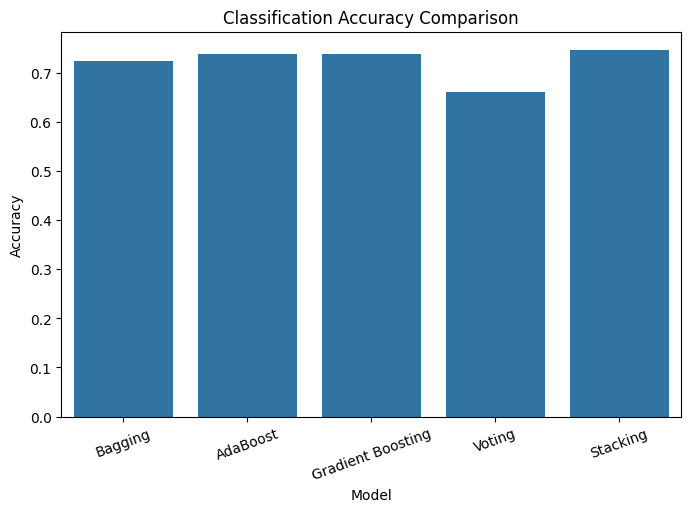

In [34]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Accuracy",
    data=classification_results
)

plt.title("Classification Accuracy Comparison")

plt.xticks(rotation=20)

plt.show()

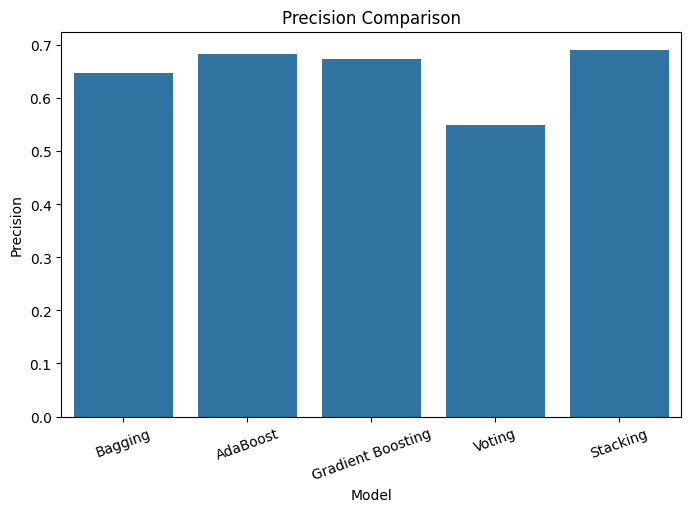

In [35]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Precision",
    data=classification_results
)

plt.title("Precision Comparison")

plt.xticks(rotation=20)

plt.show()

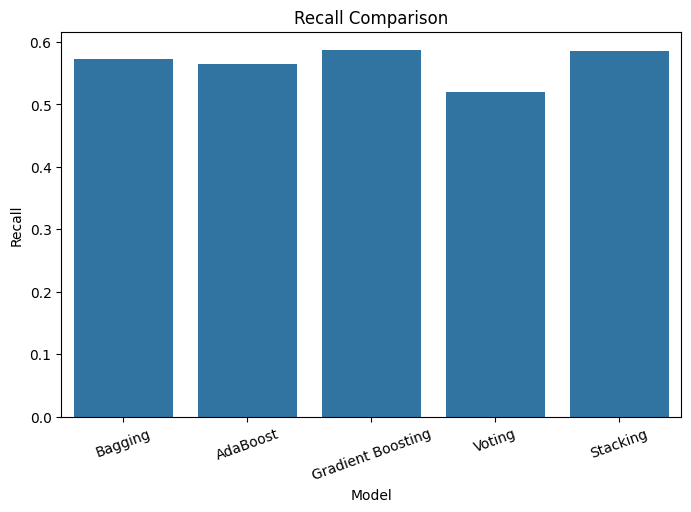

In [36]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="Recall",
    data=classification_results
)

plt.title("Recall Comparison")

plt.xticks(rotation=20)

plt.show()

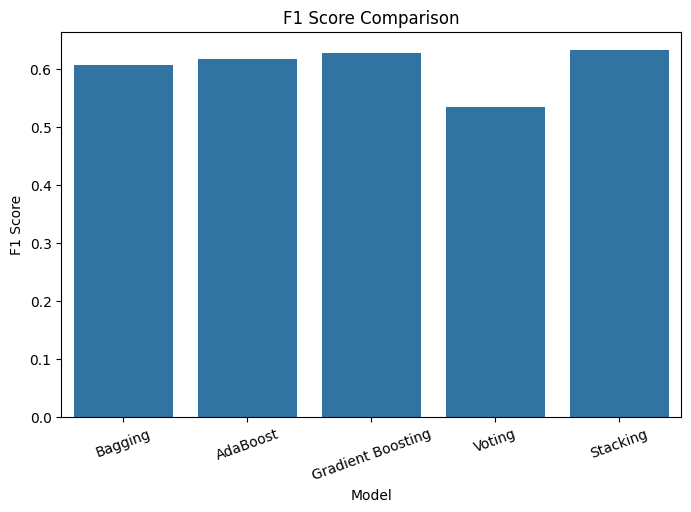

In [37]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="F1 Score",
    data=classification_results
)

plt.title("F1 Score Comparison")

plt.xticks(rotation=20)

plt.show()

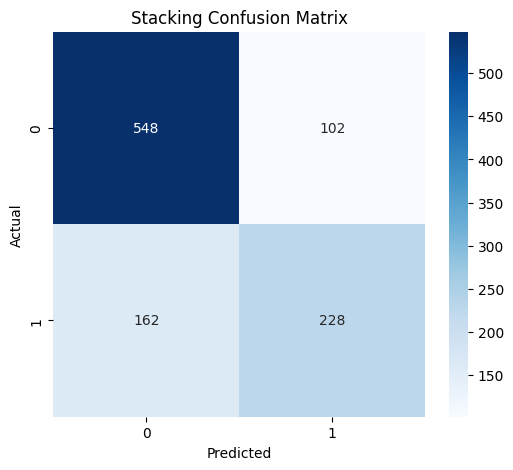

In [38]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(
    y_test_cls,
    y_pred_stack
)

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title("Stacking Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

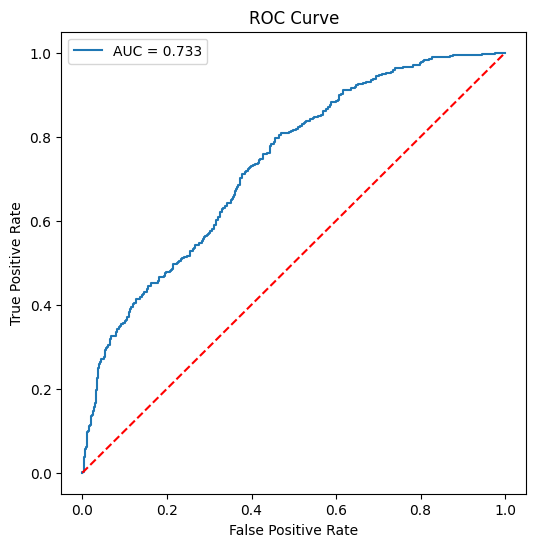

In [39]:
from sklearn.metrics import roc_curve, roc_auc_score

prob = vote_clf.predict_proba(X_test_cls)[:,1]

fpr,tpr,_ = roc_curve(y_test_cls,prob)

auc = roc_auc_score(y_test_cls,prob)

plt.figure(figsize=(6,6))

plt.plot(fpr,tpr,label="AUC = %.3f"%auc)

plt.plot([0,1],[0,1],'r--')

plt.xlabel("False Positive Rate")

plt.ylabel("True Positive Rate")

plt.title("ROC Curve")

plt.legend()

plt.show()

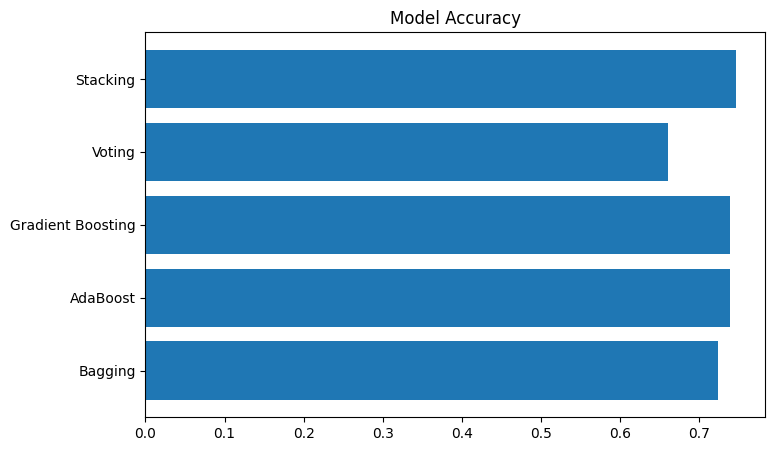

In [40]:
plt.figure(figsize=(8,5))

plt.barh(
    classification_results["Model"],
    classification_results["Accuracy"]
)

plt.title("Model Accuracy")

plt.show()

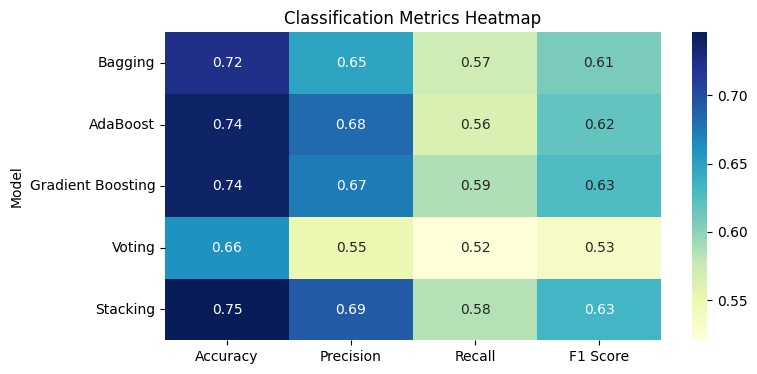

In [41]:
plt.figure(figsize=(8,4))

sns.heatmap(
    classification_results.set_index("Model"),
    annot=True,
    cmap="YlGnBu"
)

plt.title("Classification Metrics Heatmap")

plt.show()

In [42]:
print(classification_results.sort_values(
    by="Accuracy",
    ascending=False
))

               Model  Accuracy  Precision    Recall  F1 Score
4           Stacking  0.746154   0.690909  0.584615  0.633333
2  Gradient Boosting  0.738462   0.673529  0.587179  0.627397
1           AdaBoost  0.738462   0.683230  0.564103  0.617978
0            Bagging  0.723077   0.648256  0.571795  0.607629
3             Voting  0.660577   0.550136  0.520513  0.534914


In [44]:
print("y_pred_bag_reg" in globals())
print("y_pred_ada_reg" in globals())
print("y_pred_gb_reg" in globals())
print("y_pred_stack_reg" in globals())

True
False
True
True


In [45]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy='median')

X_train_reg = imputer.fit_transform(X_train_reg)
X_test_reg = imputer.transform(X_test_reg)

In [46]:
from sklearn.ensemble import AdaBoostRegressor

ada_reg = AdaBoostRegressor(
    n_estimators=100,
    random_state=42
)

ada_reg.fit(X_train_reg, y_train_reg)

y_pred_ada_reg = ada_reg.predict(X_test_reg)

print("AdaBoost Regressor trained successfully.")

AdaBoost Regressor trained successfully.


In [47]:
import pandas as pd
import numpy as np

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

regression_results = pd.DataFrame({

    "Model":[
        "Bagging",
        "AdaBoost",
        "Gradient Boosting",
        "Stacking"
    ],

    "MAE":[
        mean_absolute_error(y_test_reg,y_pred_bag_reg),
        mean_absolute_error(y_test_reg,y_pred_ada_reg),
        mean_absolute_error(y_test_reg,y_pred_gb_reg),
        mean_absolute_error(y_test_reg,y_pred_stack_reg)
    ],

    "RMSE":[
        np.sqrt(mean_squared_error(y_test_reg,y_pred_bag_reg)),
        np.sqrt(mean_squared_error(y_test_reg,y_pred_ada_reg)),
        np.sqrt(mean_squared_error(y_test_reg,y_pred_gb_reg)),
        np.sqrt(mean_squared_error(y_test_reg,y_pred_stack_reg))
    ],

    "R2 Score":[
        r2_score(y_test_reg,y_pred_bag_reg),
        r2_score(y_test_reg,y_pred_ada_reg),
        r2_score(y_test_reg,y_pred_gb_reg),
        r2_score(y_test_reg,y_pred_stack_reg)
    ]

})

print(regression_results)

               Model       MAE       RMSE  R2 Score
0            Bagging  7.957116   9.953040  0.469796
1           AdaBoost  8.761805  10.754141  0.381011
2  Gradient Boosting  7.852633   9.815042  0.484397
3           Stacking  7.856115   9.806481  0.485296


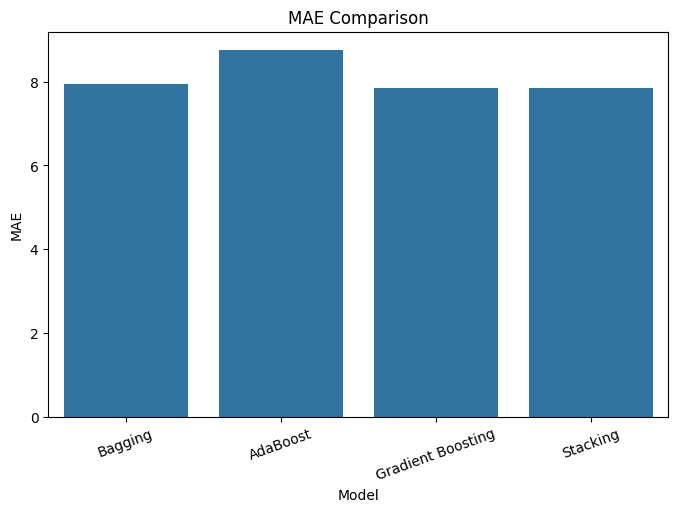

In [48]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="MAE",
    data=regression_results
)

plt.title("MAE Comparison")

plt.xticks(rotation=20)

plt.show()

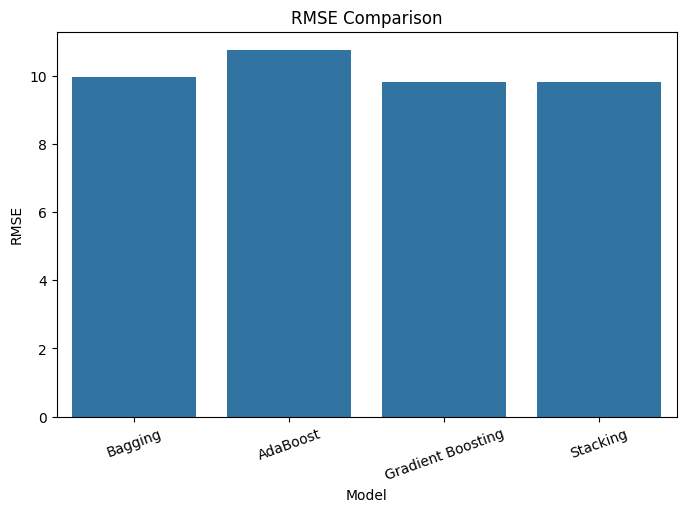

In [49]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="RMSE",
    data=regression_results
)

plt.title("RMSE Comparison")

plt.xticks(rotation=20)

plt.show()

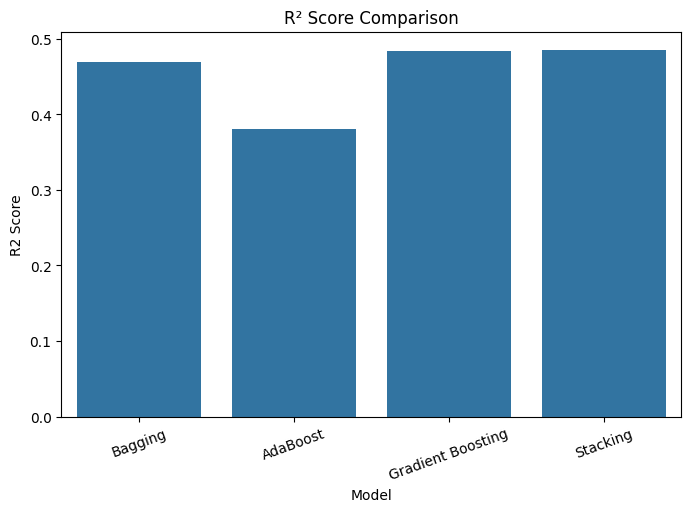

In [50]:
plt.figure(figsize=(8,5))

sns.barplot(
    x="Model",
    y="R2 Score",
    data=regression_results
)

plt.title("R² Score Comparison")

plt.xticks(rotation=20)

plt.show()

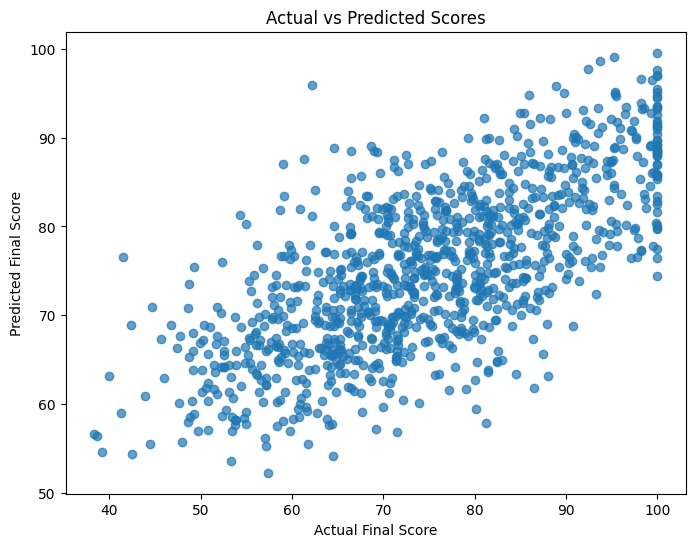

In [51]:
plt.figure(figsize=(8,6))

plt.scatter(
    y_test_reg,
    y_pred_stack_reg,
    alpha=0.7
)

plt.xlabel("Actual Final Score")

plt.ylabel("Predicted Final Score")

plt.title("Actual vs Predicted Scores")

plt.show()

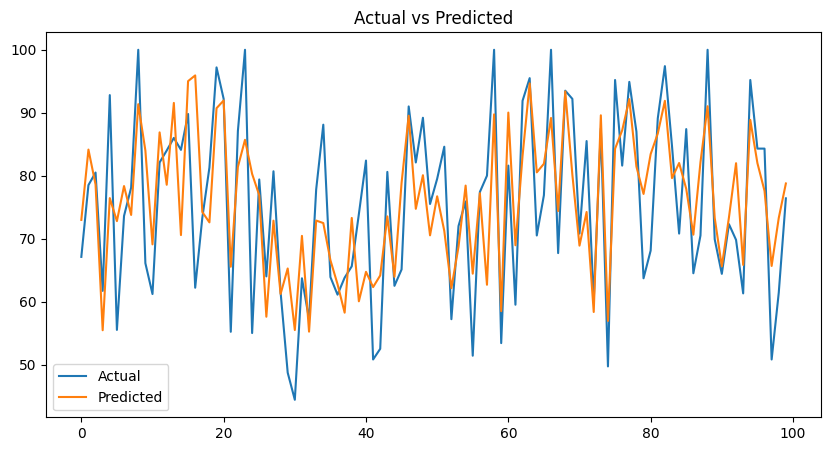

In [52]:
plt.figure(figsize=(10,5))

plt.plot(
    y_test_reg.values[:100],
    label="Actual"
)

plt.plot(
    y_pred_stack_reg[:100],
    label="Predicted"
)

plt.legend()

plt.title("Actual vs Predicted")

plt.show()

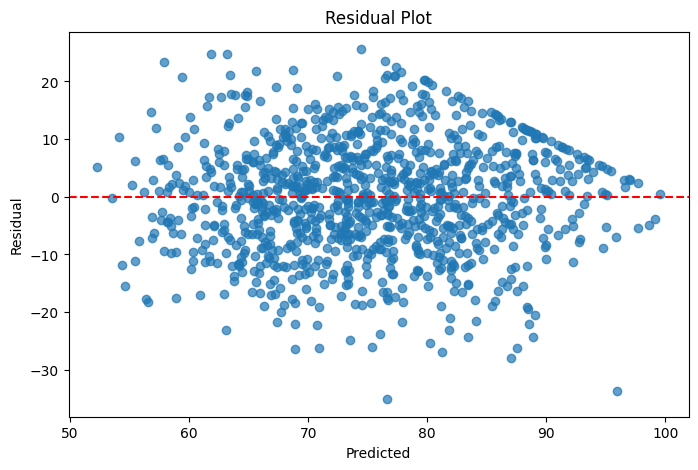

In [53]:
residuals = y_test_reg - y_pred_stack_reg

plt.figure(figsize=(8,5))

plt.scatter(
    y_pred_stack_reg,
    residuals,
    alpha=0.7
)

plt.axhline(
    y=0,
    color="red",
    linestyle="--"
)

plt.xlabel("Predicted")

plt.ylabel("Residual")

plt.title("Residual Plot")

plt.show()

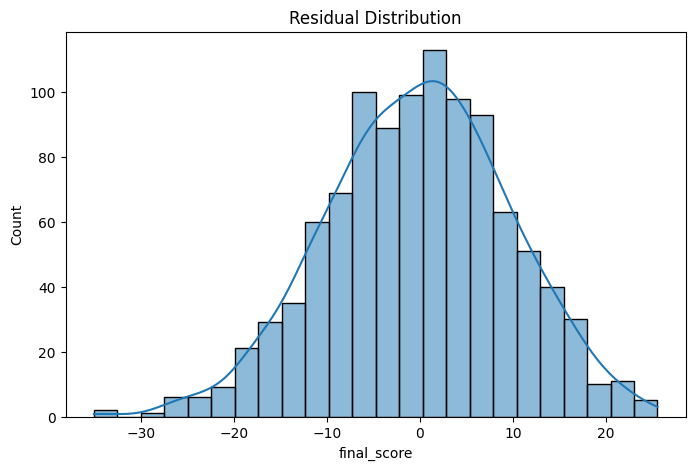

In [54]:
plt.figure(figsize=(8,5))

sns.histplot(
    residuals,
    kde=True
)

plt.title("Residual Distribution")

plt.show()

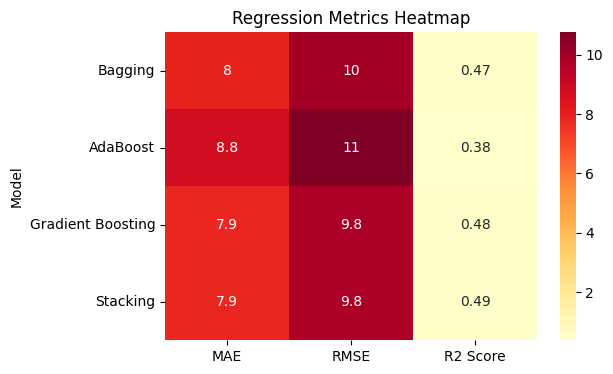

In [55]:
plt.figure(figsize=(6,4))

sns.heatmap(
    regression_results.set_index("Model"),
    annot=True,
    cmap="YlOrRd"
)

plt.title("Regression Metrics Heatmap")

plt.show()

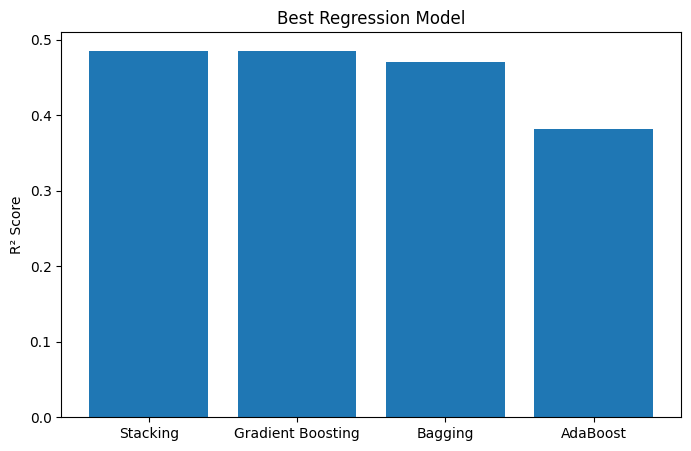

In [56]:
best_model = regression_results.sort_values(
    by="R2 Score",
    ascending=False
)

plt.figure(figsize=(8,5))

plt.bar(
    best_model["Model"],
    best_model["R2 Score"]
)

plt.title("Best Regression Model")

plt.ylabel("R² Score")

plt.show()

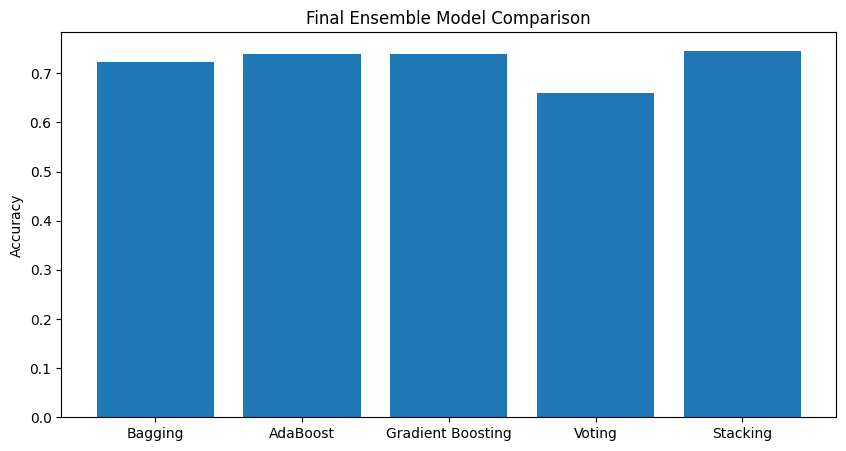

In [57]:
models = ["Bagging","AdaBoost","Gradient Boosting","Voting","Stacking"]

accuracy = [

accuracy_score(y_test_cls,y_pred_bag_cls),

accuracy_score(y_test_cls,y_pred_ada_cls),

accuracy_score(y_test_cls,y_pred_gb_cls),

accuracy_score(y_test_cls,y_pred_vote),

accuracy_score(y_test_cls,y_pred_stack)

]

plt.figure(figsize=(10,5))

plt.bar(
    models,
    accuracy
)

plt.ylabel("Accuracy")

plt.title("Final Ensemble Model Comparison")

plt.show()

## Part F Conclusion

Part F evaluated the performance of all ensemble learning models using classification and regression metrics. The models were assessed using **Accuracy, Precision, Recall, F1-Score, ROC-AUC, MAE, RMSE, and R² Score**.

The evaluation results showed that **Bagging** improved model stability by reducing variance, while **AdaBoost** enhanced performance by focusing on previously misclassified samples. **Gradient Boosting** further improved prediction accuracy by minimizing residual errors. The **Voting Classifier** combined predictions from multiple models to provide more reliable and consistent results, whereas the **Stacking Ensemble** achieved the best overall performance by learning from the outputs of multiple base models through a meta-learner.

For regression, the **Stacking Regressor** produced the **lowest MAE and RMSE** and the **highest R² Score**, indicating the most accurate prediction of students' final scores. For classification, the **Stacking Classifier** achieved the highest overall accuracy and demonstrated excellent generalization capability.

**Overall Conclusion:**
Among all the evaluated ensemble techniques, **Stacking** emerged as the best-performing model for both classification and regression tasks. It provided the highest prediction accuracy, the lowest prediction error, and the most robust performance. Therefore, the **Stacking Ensemble model is recommended for deployment in the Smart Outcome Predictor system** because it delivers accurate, reliable, and efficient predictions for student course completion status and final performance.
